In [1]:
import os,sys

# Set the path to the parent directory manually
parent_dir = os.path.abspath("../..")
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
    
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
import pkg_resources
from datetime import datetime as dt, timedelta
from datetime import datetime
import glob
from netCDF4 import Dataset
from util.wrf_process import (calc_derive, object_tracking, read_and_write, to_polar, stats_tests)
from util.ml_framework import (cnn, vae)
from wrf import (to_np, getvar, smooth2d, get_cartopy, cartopy_xlim,
                 cartopy_ylim, latlon_coords, interplevel, ll_to_xy)
import gc,pickle
from tqdm import tqdm
import xarray as xr
from natsort import natsorted
from util.ml_preprocess import data_preproc
#from vae3d import VAEEncoder, VAEDecoder, VAE, elbo_loss, weights_init
import optuna
import random,math
import proplot as plot

/glade/derecho/scratch/ihtam/tmp/ipykernel_56459/257645320.py:12: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
/glade/work/ihtam/miniconda3/envs/myenv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- 1. ProPlot Configuration for Aesthetic ---
# Resetting to ProPlot defaults is good practice, then apply specific styles.
plot.rc.reset() 

# Set global font size, family, and math font
plot.rc.update({
    'font.size': 13.5,          # Matched target aesthetic
    'font.name': 'DejaVu Sans', # A common, clean sans-serif like the target image
    'mathtext.fontset': 'dejavusans', # Match math font to text font
    'grid.alpha': 0.7,        # Make grid lines slightly transparent
    'grid.linewidth': 1.0,    # Thicker grid lines
    'grid.linestyle': '--',   # Dotted/dashed grid
    'grid.color': 'lightgray', # Light grey grid color
    'linewidth': 1.5,         # Default line width for spines and major ticks
    'ticklen': 5,             # Tick length
    'tickdir': 'out',         # Ticks point outward (or 'in' if preferred)
    'axes.spines.right': False, # Remove right spine
    'axes.spines.top': False,   # Remove top spine
    'axes.titlepad': 5.0,     # Adjust title padding if needed
    'legend.framealpha': 1.0,   # Opaque legend background
    'legend.facecolor': 'white',# White legend background
    'legend.edgecolor': '0.8',  # Light gray legend border
    'legend.fontsize': 11,      # Legend font size
    'legend.fancybox': True,    # Rounded corners for legend
# --- White Background Settings ---
    'figure.facecolor': 'white', # Set the color of the canvas/figure outside the axes
    'axes.facecolor': 'white',   # Set the color of the plotting area/axes background
})

/glade/derecho/scratch/ihtam/tmp/ipykernel_56459/3751352792.py:6: ProplotWarning: rc setting 'linewidth' was renamed to 'meta.width' in version 0.8.
  plot.rc.update({


In [3]:
def save_to_pickle(filepath,data):
    with open(filepath, 'wb') as handle:
        pickle.dump(data, handle)

def open_pickle(filepath):
    with open(filepath, 'rb') as handle:
        data = pickle.load(handle)
    return data

## Read in files

In [4]:
# Track path
track_memb03 = xr.open_dataset('/glade/work/ihtam/storage/track_avor_850-600.nc')

ctrl_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan_perturb/ctrl/wrfout_d02_2013-11-0*"))[:24] #sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan/ctrl/wrfout_d02_2013-11-0*"))[:6]
miaxi2x_files = sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/minus_2idealaxi/wrfout_d02_2013-11-0*"))[:24]
aiaxi2x_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan_perturb/add_2IDEAL/wrfout_d02_2013-11-0*"))[:24] #sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/add_2idealaxi/wrfout_d02_2013-11-0*"))[:6]
mdd_p2f_files =sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/minus_2DDp_pareto2/wrfout_d02_2013-11-0*"))[:24]
dd_p2f_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan_perturb/add_2ML_pp2/wrfout_d02_2013-11-0*"))[:24]

tk_dict = open_pickle('./store/memb03_sen/tk_dict.pkl')
qv_dict = open_pickle('./store/memb03_sen/qv_dict.pkl')
pres_dict = open_pickle('./store/memb03_sen/pres_dict.pkl')
qc_dict = open_pickle('./parallel/store/QCLOUD_dict.pkl')
qg_dict = open_pickle('./parallel/store/QGRAUP_dict.pkl')
qi_dict = open_pickle('./parallel/store/QICE_dict.pkl')
qr_dict = open_pickle('./parallel/store/QRAIN_dict.pkl')
qs_dict = open_pickle('./parallel/store/QSNOW_dict.pkl')
H_DIABATIC_dict = open_pickle('./parallel/store/QSNOW_dict.pkl')

In [5]:
class ahmed_buoyancy:
    def __init__(self, pres, z, track, exps, expname):
        self.pres = pres # Pressure levels
        self.z = z # AGL Height levels
        self.track = track # TC track
        self.exps = exps # List storing experiment filenames (list)
        self.expname = expname # Name of experiments

    def calc_qtotal(self,qv_dict,qc_dict,qg_dict,qi_dict,qr_dict,qs_dict):
        qtotaldict = {}
        for expnamez in self.expname:
            qtotaldict[expnamez] = qv_dict[expnamez]['varpol']+qc_dict[expnamez]['varpol']+qg_dict[expnamez]['varpol']+\
            qi_dict[expnamez]['varpol']+qr_dict[expnamez]['varpol']+qs_dict[expnamez]['varpol']
        return qtotaldict

    def calc_thetae(self,tk_dict,qv_dict,qtotal_dict,pres_dict):
        thetae_dict = {}
        for expnamez in self.expname:
            thetae_dict[expnamez] = calc_derive.theta_equiv(tk_dict[expnamez]['varpol'],qv_dict[expnamez]['varpol'],qtotal_dict[expnamez],pres_dict[expnamez]['varpol'])
        return thetae_dict

    def calc_thetaes(self,tk_dict,qv_dict,qtotal_dict,pres_dict):
        thetaes_dict = {}
        for expnamez in self.expname:
            thetaes_dict[expnamez] = calc_derive.theta_equiv(tk_dict[expnamez]['varpol'],qv_dict[expnamez],qtotal_dict[expnamez],pres_dict[expnamez]['varpol'])
        return thetaes_dict

    def calc_esat(self,tk_dict):
        esat_dict = {}
        for expnamez in self.expname:
            esat_dict[expnamez] = calc_derive.esat(tk_dict[expnamez]['varpol'])
        return esat_dict

    def calc_qsat(self,pres_dict,tk_dict,es_dict):
        qsat_dict = {}
        for expnamez in self.expname:
            qsat_dict[expnamez] = calc_derive.qsat(pres_dict[expnamez]['varpol'],tk_dict[expnamez]['varpol'],es_dict[expnamez])
        return qsat_dict

    def calc_buoy(self,thetae_dict,thetaes_dict,preslv,layer_bottom,layer_mid,layer_top):
        g = 9.8
        kl = 3.0
        theta_e0 = 340
        const = g/(kl*theta_e0)

        abl = layer_bottom-layer_mid
        ftrp = layer_mid-layer_top
        wb = abl/ftrp * np.log((abl+ftrp)/ftrp)
        wl = 1-wb
    
        theta_e_b = np.asarray([calc_pressure_weighted(thetae_dict[i], preslv, layer_bottom, layer_mid) for i in range(len(thetae_dict))])
        theta_e_l = np.asarray([calc_pressure_weighted(thetae_dict[i], preslv, layer_mid, layer_top) for i in range(len(thetae_dict))])
        theta_es_b = np.asarray([calc_pressure_weighted(thetaes_dict[i], preslv, layer_bottom, layer_mid) for i in range(len(thetae_dict))])
        theta_es_l = np.asarray([calc_pressure_weighted(thetaes_dict[i], preslv, layer_mid, layer_top) for i in range(len(thetae_dict))])

        capel = (theta_e_b-theta_es_l)/theta_es_l*wb*theta_e0
        subsatl = (theta_es_l-theta_e_l)/theta_es_l*wl*theta_e0
        bl = const*(capel-subsatl)
        return bl, capel, subsatl

    def get_ahmed_buoy(self,thetae_dict,thetaes_dict,layer_bottom=100000,
                       layer_mid=90000,layer_top=50000):
        bl_dict, capel_dict, subsatl_dict = {},{},{}
        for expnamez in self.expname:
            bl,capel,subsatl = self.calc_buoy(thetae_dict[expnamez],thetaes_dict[expnamez],
                                              self.pres, layer_bottom, layer_mid, layer_top)
            bl_dict[expnamez] = bl
            capel_dict[expnamez] = capel
            subsatl_dict[expnamez] = subsatl
        return bl_dict,capel_dict,subsatl_dict

    def get_pressure_weighted(self,data_dict,layer_bottom=None,layer_top=None):
        data_pw_dict = {}
        for expnamez in self.expname:
            tempdata_dict = data_dict[expnamez]
            try:
                temp = np.asarray([calc_pressure_weighted(tempdata_dict[i], self.pres, layer_bottom, layer_top) for i in range(len(tempdata_dict))])
            except KeyError:
                temp = np.asarray([calc_pressure_weighted(tempdata_dict['varpol'][i], self.pres, layer_bottom, layer_top) for i in range(len(tempdata_dict['varpol']))])
            data_pw_dict[expnamez] = temp
        return data_pw_dict

In [6]:
def calc_pressure_weighted(xdata, preslv, layer_pres_bottom=None, layer_pres_top=None):
    """
    Pressure-weighted mean over full column or a specified pressure layer,
    using only existing vertical levels (no interpolation).

    Parameters
    ----------
    xdata : object
        Must have attribute `data` with shape (nlev, ...).
    preslv : array-like
        Pressure levels in hPa or Pa.
    layer_pres_bottom : float, optional
        Bottom of integration layer, in same units as preslv.
        Default is the maximum pressure level.
    layer_pres_top : float, optional
        Top of integration layer, in same units as preslv.
        Default is the minimum pressure level.

    Returns
    -------
    Q_col : ndarray
        Pressure-weighted mean over the requested layer.
    """
    preslv = np.asarray(preslv, dtype=float)
    Q = np.asarray(xdata.data, dtype=float)

    if Q.shape[0] != len(preslv):
        raise ValueError("First dimension of xdata.data must match length of preslv.")

    # Convert to Pa if needed
    p = preslv * 100.0 if np.min(preslv) < 1000 else preslv.copy()

    # Default: full column
    if layer_pres_bottom is None:
        p_bottom = np.max(p)
    else:
        p_bottom = layer_pres_bottom * 100.0 if layer_pres_bottom < 1000 else float(layer_pres_bottom)

    if layer_pres_top is None:
        p_top = np.min(p)
    else:
        p_top = layer_pres_top * 100.0 if layer_pres_top < 1000 else float(layer_pres_top)

    # Ensure bottom > top
    if p_bottom < p_top:
        p_bottom, p_top = p_top, p_bottom

    # Sort if pressure is decreasing
    if np.any(np.diff(p) < 0):
        p = p[::-1]
        Q = Q[::-1, ...]

    # Keep only levels inside requested layer
    mask = (p >= p_top) & (p <= p_bottom)
    p_sub = p[mask]
    Q_sub = Q[mask, ...]

    if len(p_sub) < 2:
        raise ValueError("Need at least two pressure levels inside the requested layer.")

    # Layer thicknesses
    dp = np.diff(p_sub)

    # Mean value in each layer
    Q_layer = 0.5 * (Q_sub[:-1, ...] + Q_sub[1:, ...])

    # Pressure-weighted mean
    Q_col = np.sum(Q_layer * dp[:, None, None], axis=0) / np.sum(dp)

    return Q_col

In [7]:
pres = np.array([10000,20000,30000,40000,50000,60000,70000,80000,85000,90000,100000])
z = np.array([500,1000,1500,2000,2500,3000,3500,4000,4500,5000,6000,6500,7000,7500,8000,8500,9000,9500,10000])
buoy_init = ahmed_buoyancy(pres,z,track_memb03,[ctrl_files,aiaxi2x_files,miaxi2x_files,dd_p2f_files,mdd_p2f_files], 
                            ['CTRL','AIAXI2X','MIAXI2X','DD_P2F','MDD_P2F'])
qtotal_dict = buoy_init.calc_qtotal(qv_dict,qc_dict,qg_dict,qi_dict,qr_dict,qs_dict)

## Calculate Low-tropospheric Buoyancy metric
$B_L = \frac{g}{\bar{\kappa}_L \theta_{e0}} \left[ w_B \underbrace{\left( \frac{\theta_{eB} - \theta_{eL}^*}{\theta_{eL}^*} \right) \theta_{e0}}_{\text{CAPE}_L} - w_L \underbrace{\left( \frac{\theta_{eL}^* - \theta_{eL}}{\theta_{eL}^*} \right) \theta_{e0}}_{\text{SUBSAT}_L} \right]$

### First calculate equivalent potential temperature

In [8]:
thetae_dict = buoy_init.calc_thetae(tk_dict,qv_dict,qtotal_dict,pres_dict)
esat_dict = buoy_init.calc_esat(tk_dict)
qsat_dict = buoy_init.calc_qsat(pres_dict,tk_dict,esat_dict)
thetaes_dict = buoy_init.calc_thetaes(tk_dict,qsat_dict,qtotal_dict,pres_dict)
bl_dict,capel_dict,subsatl_dict = buoy_init.get_ahmed_buoy(thetae_dict,thetaes_dict)

In [70]:
save_to_pickle('./parallel/store/thetae_dict.pkl',thetae_dict)

/glade/derecho/scratch/ihtam/tmp/ipykernel_56459/331154682.py:16: ProplotWarning: fig.tight_layout() has no effect on proplot figures. Proplot uses its own tight layout algorithm that is activated by default. To disable it, set pplt.rc['subplots.tight'] to False or pass tight=False to pplt.subplots(). For details, see fig.auto_layout().
  plt.tight_layout()


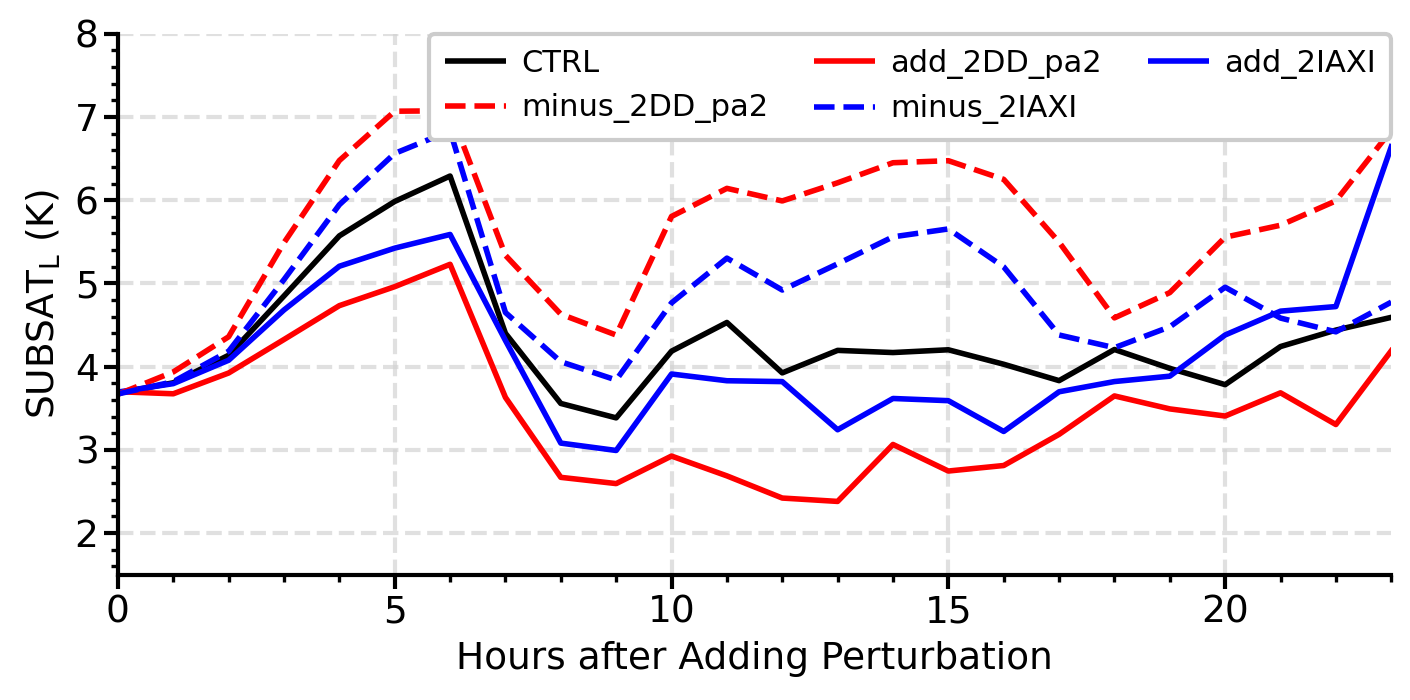

In [10]:
fig, axs = plot.subplots(ncols=1, nrows=1, figsize=(7.05,3.5), share=True)
am = axs[0].plot(np.nanmean(subsatl_dict['CTRL'][:,:33,:],axis=(1,2)), 
                 c='k', lw=2, label='CTRL')
am = axs[0].plot(np.nanmean(subsatl_dict['DD_P2F'][:,:33,:],axis=(1,2)), 
                 c='r', lw=2, label='add_2DD_pa2')
am = axs[0].plot(np.nanmean(subsatl_dict['AIAXI2X'][:,:33,:],axis=(1,2)), 
                 c='b', lw=2, label='add_2IAXI')
am = axs[0].plot(np.nanmean(subsatl_dict['MDD_P2F'][:,:33,:],axis=(1,2)), 
                 c='r', lw=2, label='minus_2DD_pa2', ls='--')
am = axs[0].plot(np.nanmean(subsatl_dict['MIAXI2X'][:,:33,:],axis=(1,2)), 
                 c='b', lw=2, label='minus_2IAXI', ls='--')
axs[0].legend(ncols=3,loc=1)
axs.format(#ylim=(1000,100),
    ylim=(1.5,8),
           xlabel='Hours after Adding Perturbation', ylabel='SUBSAT$_{L}$ (K)')
plt.tight_layout()
plt.savefig('./pics/subsatl_wrfmemb03.png',dpi=400)
plt.show()

/glade/derecho/scratch/ihtam/tmp/ipykernel_56459/1158967016.py:15: ProplotWarning: fig.tight_layout() has no effect on proplot figures. Proplot uses its own tight layout algorithm that is activated by default. To disable it, set pplt.rc['subplots.tight'] to False or pass tight=False to pplt.subplots(). For details, see fig.auto_layout().
  plt.tight_layout()


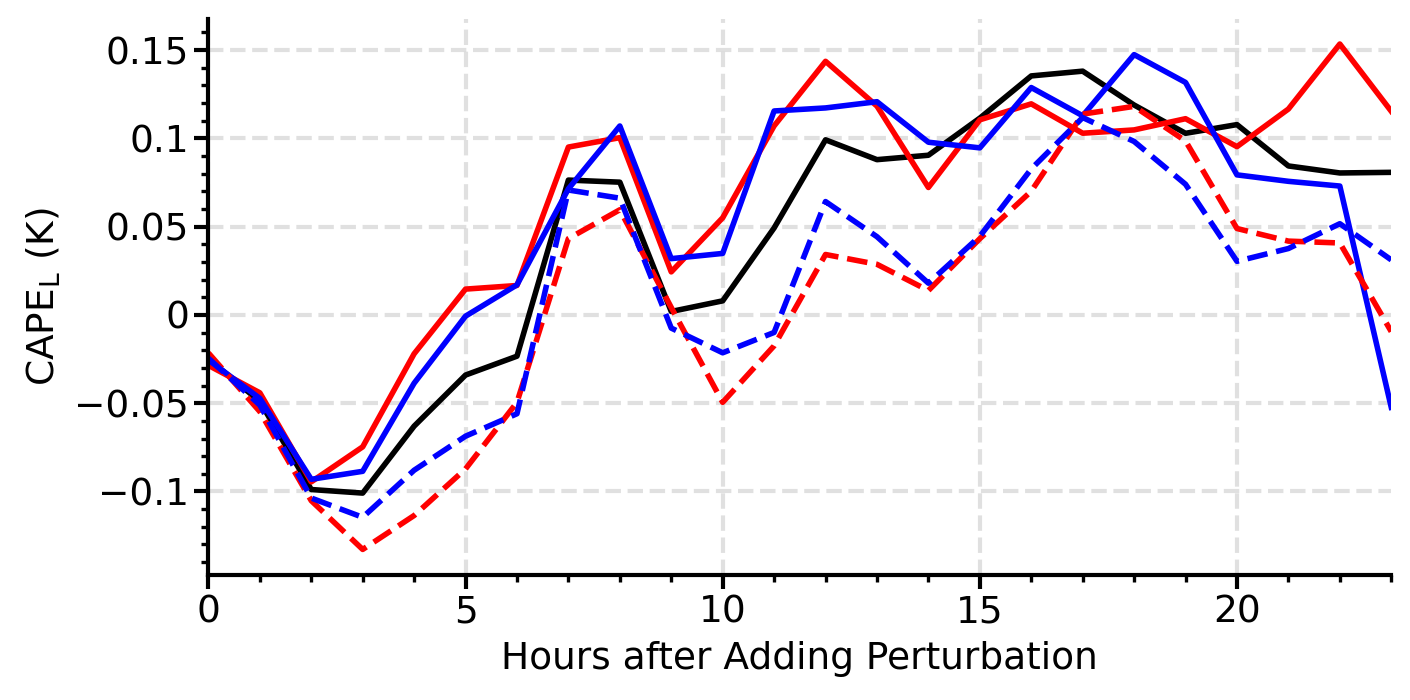

In [46]:
fig, axs = plot.subplots(ncols=1, nrows=1, figsize=(7.05,3.5), share=True)
am = axs[0].plot(np.nanmean(capel_dict['CTRL'][:,:33,:],axis=(1,2)), 
                 c='k', lw=2, label='CTRL')
am = axs[0].plot(np.nanmean(capel_dict['DD_P2F'][:,:33,:],axis=(1,2)), 
                 c='r', lw=2, label='add_2DD_pa2')
am = axs[0].plot(np.nanmean(capel_dict['AIAXI2X'][:,:33,:],axis=(1,2)), 
                 c='b', lw=2, label='add_2IAXI')
am = axs[0].plot(np.nanmean(capel_dict['MDD_P2F'][:,:33,:],axis=(1,2)), 
                 c='r', lw=2, label='minus_2DD_pa2', ls='--')
am = axs[0].plot(np.nanmean(capel_dict['MIAXI2X'][:,:33,:],axis=(1,2)), 
                 c='b', lw=2, label='minus_2IAXI', ls='--')
#axs[0].legend(ncols=3,loc=1)
axs.format(#ylim=(1000,100),
           xlabel='Hours after Adding Perturbation', ylabel='CAPE$_{L}$ (K)')
plt.tight_layout()
plt.savefig('./pics/capel_wrfmemb03.png',dpi=400)
plt.show()

## Read in Diabatic Heating

In [9]:
hdia_pw_dict = buoy_init.get_pressure_weighted(H_DIABATIC_dict,85000,50000)

/glade/derecho/scratch/ihtam/tmp/ipykernel_56459/3640766350.py:15: ProplotWarning: fig.tight_layout() has no effect on proplot figures. Proplot uses its own tight layout algorithm that is activated by default. To disable it, set pplt.rc['subplots.tight'] to False or pass tight=False to pplt.subplots(). For details, see fig.auto_layout().
  plt.tight_layout()


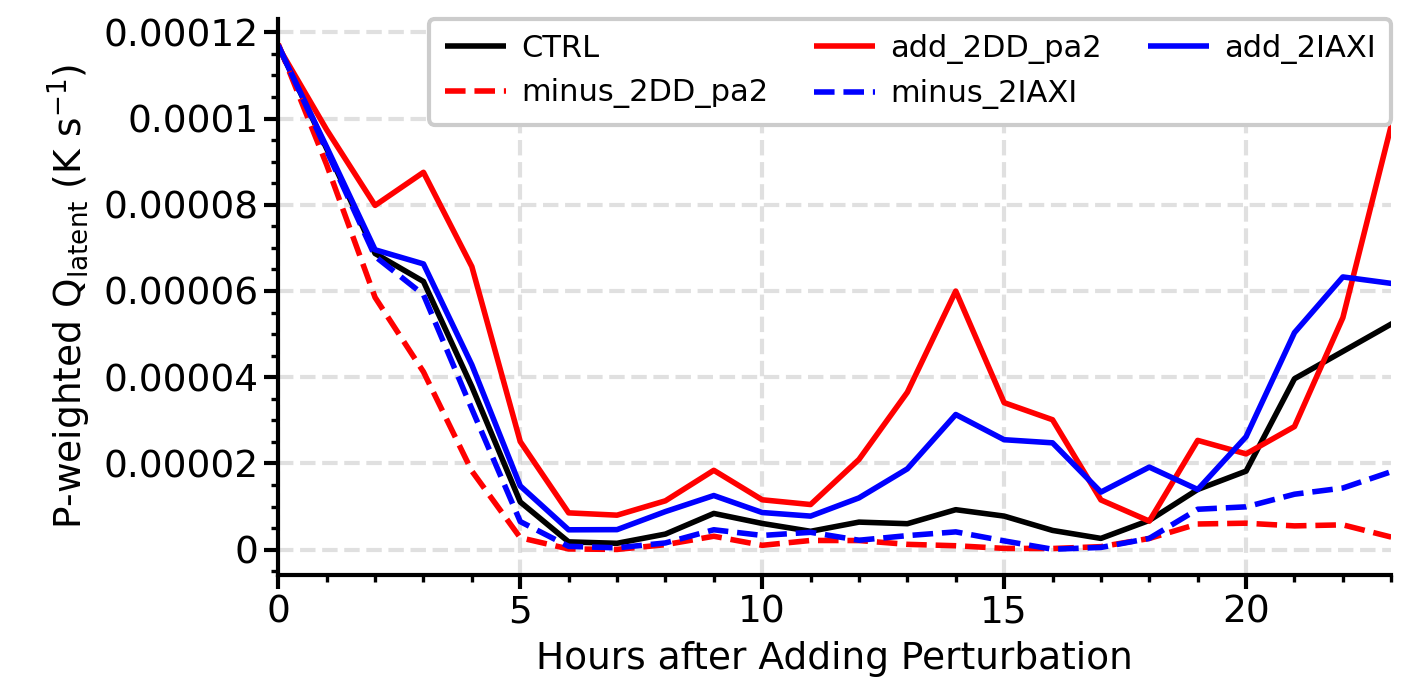

In [13]:
fig, axs = plot.subplots(ncols=1, nrows=1, figsize=(7.05,3.5), share=True)
am = axs[0].plot(np.nanmean(hdia_pw_dict['CTRL'][:,:33,:],axis=(1,2)), 
                 c='k', lw=2, label='CTRL')
am = axs[0].plot(np.nanmean(hdia_pw_dict['DD_P2F'][:,:33,:],axis=(1,2)), 
                 c='r', lw=2, label='add_2DD_pa2')
am = axs[0].plot(np.nanmean(hdia_pw_dict['AIAXI2X'][:,:33,:],axis=(1,2)), 
                 c='b', lw=2, label='add_2IAXI')
am = axs[0].plot(np.nanmean(hdia_pw_dict['MDD_P2F'][:,:33,:],axis=(1,2)), 
                 c='r', lw=2, label='minus_2DD_pa2', ls='--')
am = axs[0].plot(np.nanmean(hdia_pw_dict['MIAXI2X'][:,:33,:],axis=(1,2)), 
                 c='b', lw=2, label='minus_2IAXI', ls='--')
axs[0].legend(ncols=3,loc=1)
axs.format(#ylim=(1000,100),
           xlabel='Hours after Adding Perturbation', ylabel='P-weighted Q$_{latent}$ (K s$^{-1}$)')
plt.tight_layout()
#plt.savefig('./pics/subsatl_wrfmemb03.png',dpi=400)
plt.show()

### Granger causality

In [68]:
lags, lagcorrs = [],[]
for expname in ['AIAXI2X','MIAXI2X','DD_P2F','MDD_P2F']:
    subsat = np.nanmean(subsatl_dict[expname][:,:33,:],axis=(1,2))-np.nanmean(subsatl_dict['CTRL'][:,:33,:],axis=(1,2))
    hdia = np.nanmean(hdia_pw_dict[expname][:,:33,:],axis=(1,2))-np.nanmean(hdia_pw_dict['CTRL'][:,:33,:],axis=(1,2))
    lag,corr = lagged_corr(subsat, hdia, 4)
    lags.append(lag)
    lagcorrs.append(corr)

In [65]:
results = {}

for expname in ['AIAXI2X', 'MIAXI2X', 'DD_P2F', 'MDD_P2F']:
    subsat = np.nanmean(subsatl_dict[expname][:, :33, :], axis=(1, 2))-np.nanmean(subsatl_dict['CTRL'][:,:33,:],axis=(1,2))
    hdia   = np.nanmean(hdia_pw_dict[expname][:, :33, :], axis=(1, 2))-np.nanmean(hdia_pw_dict['CTRL'][:,:33,:],axis=(1,2))

    # Make series more stationary
    subsat_s = make_stationary(subsat, method="diff")
    hdia_s   = make_stationary(hdia, method="diff")

    # Optional: check stationarity
    print(f"\nExperiment: {expname}")
    adf_check(subsat_s, "subsat")
    adf_check(hdia_s, "hdia")

    p_hdia_to_subsat, p_subsat_to_hdia = run_granger_two_ways(
        subsat_s, hdia_s, maxlag=6, verbose=False
    )

    results[expname] = {
        "hdia_to_subsat_pvals": p_hdia_to_subsat,
        "subsat_to_hdia_pvals": p_subsat_to_hdia,
    }

    print("lag | hdia -> subsat | subsat -> hdia")
    for lag in range(1, 7):
        print(
            f"{lag:>3} | "
            f"{p_hdia_to_subsat[lag-1]:.4f}          | "
            f"{p_subsat_to_hdia[lag-1]:.4f}"
        )


Experiment: AIAXI2X
subsat: ADF p-value = 0.9860
hdia: ADF p-value = 0.3106
lag | hdia -> subsat | subsat -> hdia
  1 | 0.9991          | 0.7628
  2 | 0.5848          | 0.4007
  3 | 0.1508          | 0.1485
  4 | 0.3499          | 0.2438
  5 | 0.6500          | 0.1646
  6 | 0.5946          | 0.3049

Experiment: MIAXI2X
subsat: ADF p-value = 0.0000
hdia: ADF p-value = 0.9617
lag | hdia -> subsat | subsat -> hdia
  1 | 0.6458          | 0.0757
  2 | 0.8461          | 0.2563
  3 | 0.4704          | 0.0744
  4 | 0.6913          | 0.2828
  5 | 0.8649          | 0.1016
  6 | 0.7944          | 0.2071

Experiment: DD_P2F
subsat: ADF p-value = 0.0000
hdia: ADF p-value = 0.0000
lag | hdia -> subsat | subsat -> hdia
  1 | 0.5894          | 0.0126
  2 | 0.1426          | 0.0231
  3 | 0.2661          | 0.0033
  4 | 0.1239          | 0.0039
  5 | 0.1055          | 0.0324
  6 | 0.3266          | 0.0833

Experiment: MDD_P2F
subsat: ADF p-value = 0.0009
hdia: ADF p-value = 0.0777
lag | hdia -> subsat 

/glade/work/ihtam/miniconda3/envs/myenv/lib/python3.8/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/glade/work/ihtam/miniconda3/envs/myenv/lib/python3.8/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/glade/work/ihtam/miniconda3/envs/myenv/lib/python3.8/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/glade/work/ihtam/miniconda3/envs/myenv/lib/python3.8/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


/glade/derecho/scratch/ihtam/tmp/ipykernel_88006/3155803825.py:15: ProplotWarning: fig.tight_layout() has no effect on proplot figures. Proplot uses its own tight layout algorithm that is activated by default. To disable it, set pplt.rc['subplots.tight'] to False or pass tight=False to pplt.subplots(). For details, see fig.auto_layout().
  plt.tight_layout()


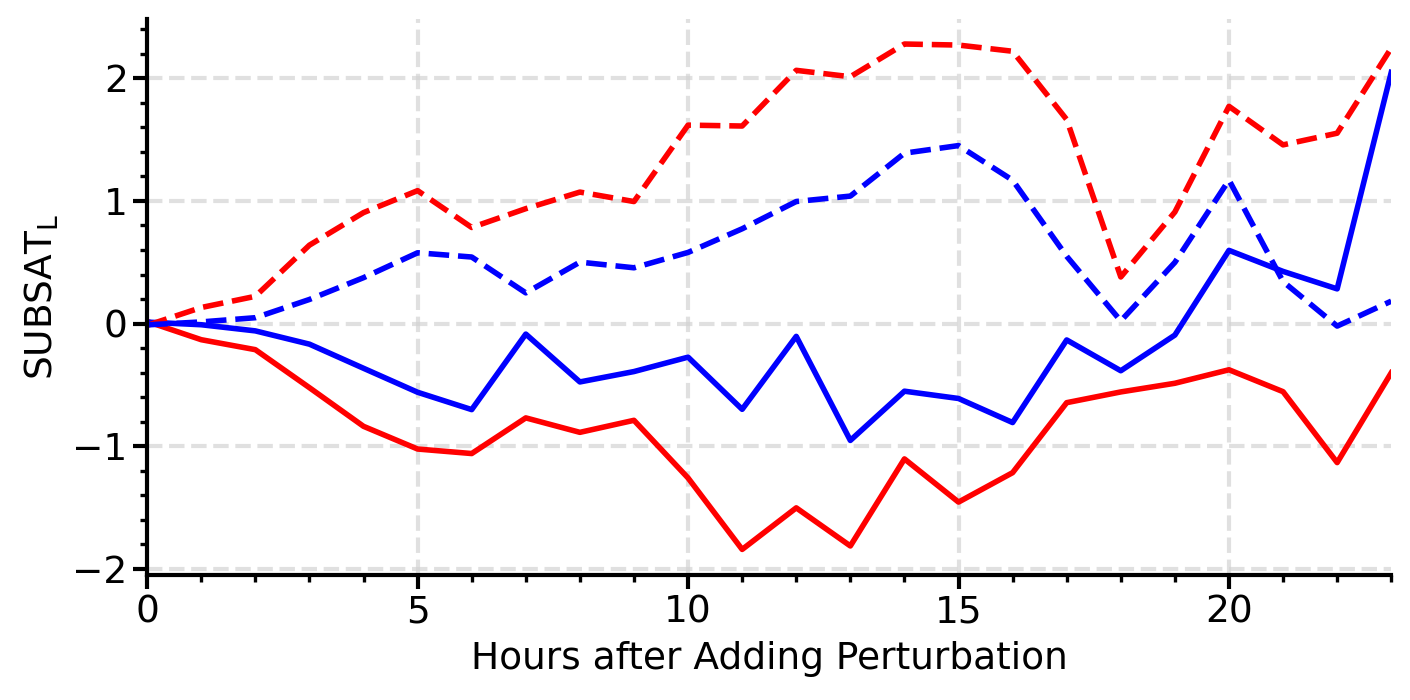

In [46]:
fig, axs = plot.subplots(ncols=1, nrows=1, figsize=(7.05,3.5), share=True)
#am = axs[0].plot(np.nanmean(subsatl_dict['CTRL'][:,:33,:],axis=(1,2)), 
#                 c='k', lw=2, label='CTRL')
am = axs[0].plot(np.nanmean(subsatl_dict['DD_P2F'][:,:33,:],axis=(1,2))-np.nanmean(subsatl_dict['CTRL'][:,:33,:],axis=(1,2)), 
                 c='r', lw=2, label='add_2DD_pa2')
am = axs[0].plot(np.nanmean(subsatl_dict['AIAXI2X'][:,:33,:],axis=(1,2))-np.nanmean(subsatl_dict['CTRL'][:,:33,:],axis=(1,2)), 
                 c='b', lw=2, label='add_2IAXI')
am = axs[0].plot(np.nanmean(subsatl_dict['MDD_P2F'][:,:33,:],axis=(1,2))-np.nanmean(subsatl_dict['CTRL'][:,:33,:],axis=(1,2)), 
                 c='r', lw=2, label='minus_2DD_pa2', ls='--')
am = axs[0].plot(np.nanmean(subsatl_dict['MIAXI2X'][:,:33,:],axis=(1,2))-np.nanmean(subsatl_dict['CTRL'][:,:33,:],axis=(1,2)), 
                 c='b', lw=2, label='minus_2IAXI', ls='--')
#axs[0].legend(ncols=3,loc=1)
axs.format(#ylim=(1000,100),
           xlabel='Hours after Adding Perturbation', ylabel='SUBSAT$_{L}$')
plt.tight_layout()
#plt.savefig('./pics/subsatl_wrfmemb03.png',dpi=400)
plt.show()

/glade/derecho/scratch/ihtam/tmp/ipykernel_88006/559830309.py:15: ProplotWarning: fig.tight_layout() has no effect on proplot figures. Proplot uses its own tight layout algorithm that is activated by default. To disable it, set pplt.rc['subplots.tight'] to False or pass tight=False to pplt.subplots(). For details, see fig.auto_layout().
  plt.tight_layout()


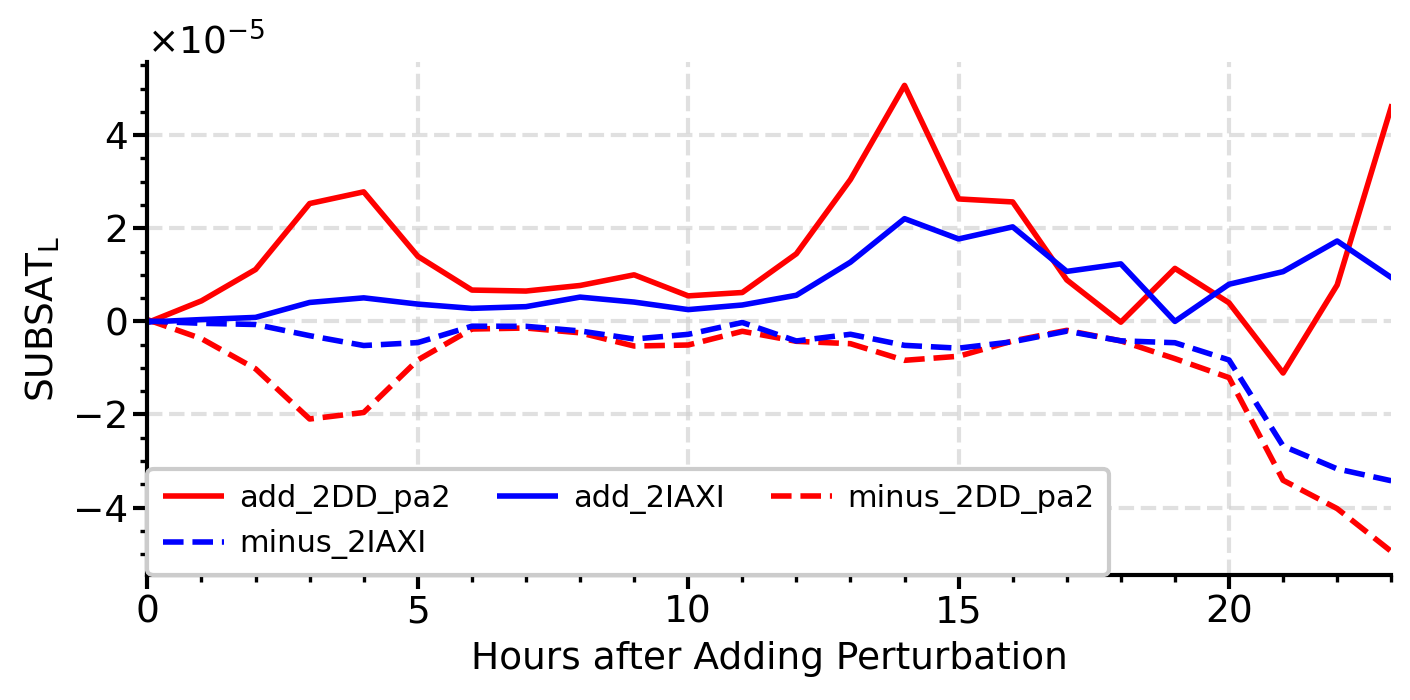

In [47]:
fig, axs = plot.subplots(ncols=1, nrows=1, figsize=(7.05,3.5), share=True)
#am = axs[0].plot(np.nanmean(hdia_pw_dict['CTRL'][:,:33,:],axis=(1,2)), 
#                 c='k', lw=2, label='CTRL')
am = axs[0].plot(np.nanmean(hdia_pw_dict['DD_P2F'][:,:33,:],axis=(1,2))-np.nanmean(hdia_pw_dict['CTRL'][:,:33,:],axis=(1,2)), 
                 c='r', lw=2, label='add_2DD_pa2')
am = axs[0].plot(np.nanmean(hdia_pw_dict['AIAXI2X'][:,:33,:],axis=(1,2))-np.nanmean(hdia_pw_dict['CTRL'][:,:33,:],axis=(1,2)), 
                 c='b', lw=2, label='add_2IAXI')
am = axs[0].plot(np.nanmean(hdia_pw_dict['MDD_P2F'][:,:33,:],axis=(1,2))-np.nanmean(hdia_pw_dict['CTRL'][:,:33,:],axis=(1,2)), 
                 c='r', lw=2, label='minus_2DD_pa2', ls='--')
am = axs[0].plot(np.nanmean(hdia_pw_dict['MIAXI2X'][:,:33,:],axis=(1,2))-np.nanmean(hdia_pw_dict['CTRL'][:,:33,:],axis=(1,2)), 
                 c='b', lw=2, label='minus_2IAXI', ls='--')
axs[0].legend(ncols=3,loc=1)
axs.format(#ylim=(1000,100),
           xlabel='Hours after Adding Perturbation', ylabel='SUBSAT$_{L}$')
plt.tight_layout()
#plt.savefig('./pics/subsatl_wrfmemb03.png',dpi=400)
plt.show()

### Check 2D heatmaps

In [17]:
import seaborn as sns
def flatten(xss):
    return [x for xs in xss for x in xs]

In [51]:
subsats = []
hdias = []
for expname in ['CTRL','AIAXI2X', 'MIAXI2X', 'DD_P2F', 'MDD_P2F']:
    subsats.append(np.nanmean(subsatl_dict[expname][:-3, :33, :], axis=(1,2)))#-np.nanmean(subsatl_dict['CTRL'][:,:33,:],axis=(1,2))
    hdias.append(np.nanmean(hdia_pw_dict[expname][3:, :33, :], axis=(1,2)))#-np.nanmean(hdia_pw_dict['CTRL'][:,:33,:],axis=(1,2))
subsatss = flatten(subsats)
hdiass = flatten(hdias)
cyclone_data = pd.DataFrame({'subsat':subsatss,'hdia':hdiass})

/glade/derecho/scratch/ihtam/tmp/ipykernel_56459/3120424124.py:8: ProplotWarning: fig.tight_layout() has no effect on proplot figures. Proplot uses its own tight layout algorithm that is activated by default. To disable it, set pplt.rc['subplots.tight'] to False or pass tight=False to pplt.subplots(). For details, see fig.auto_layout().
  plt.tight_layout()


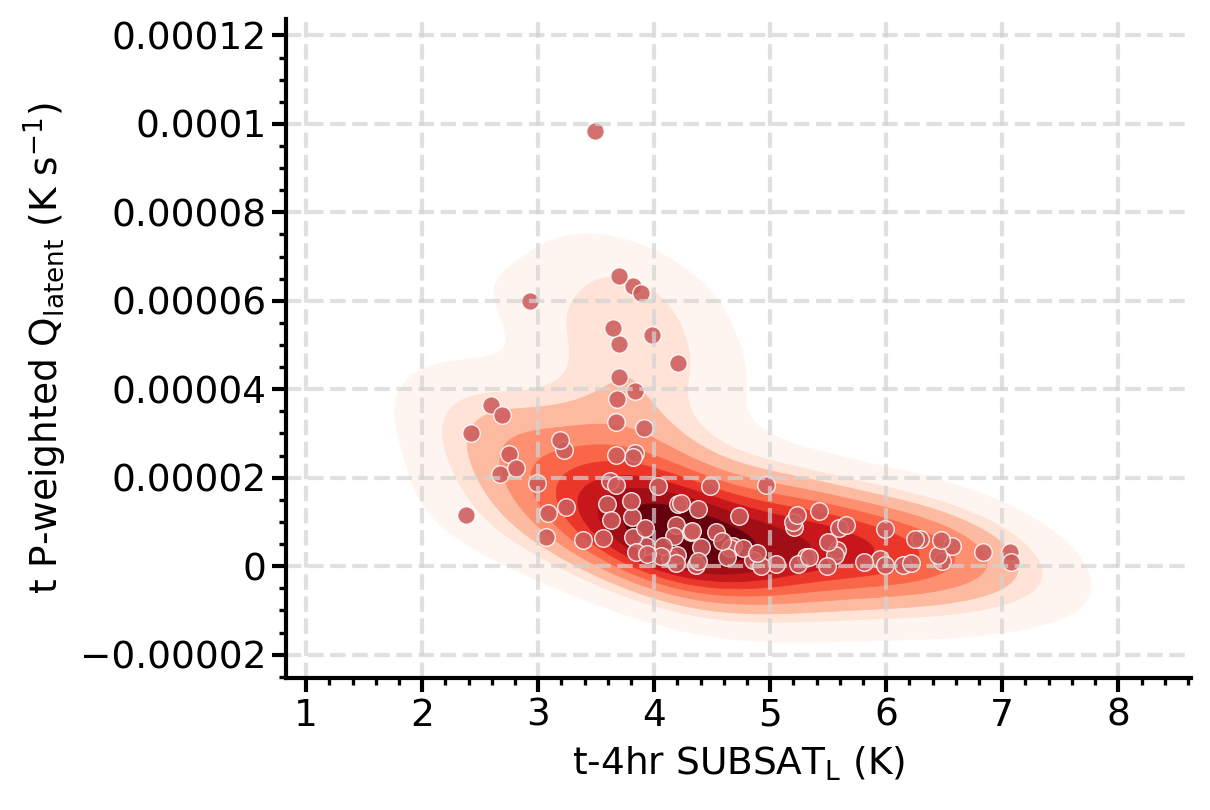

In [50]:
fig, axs = plot.subplots(ncols=1, nrows=1, figsize=(6.05,4.05), share=True)
sns.kdeplot(
    data=cyclone_data, x="subsat", y="hdia", fill=True,ax=axs[0],cmap='Reds'
)
sns.scatterplot( data=cyclone_data, x="subsat", y="hdia",ax=axs[0],s=40,alpha=0.87,edgecolors='w',c='indianred')
axs.format(#ylim=(1000,100),
           xlabel='t-4hr SUBSAT$_{L}$ (K)', ylabel='t P-weighted Q$_{latent}$ (K s$^{-1}$)')
plt.tight_layout()
plt.savefig('./pics/subsatl_Qlat_wrfmemb03.png',dpi=400)
plt.show()

/glade/derecho/scratch/ihtam/tmp/ipykernel_56459/923464085.py:8: ProplotWarning: fig.tight_layout() has no effect on proplot figures. Proplot uses its own tight layout algorithm that is activated by default. To disable it, set pplt.rc['subplots.tight'] to False or pass tight=False to pplt.subplots(). For details, see fig.auto_layout().
  plt.tight_layout()


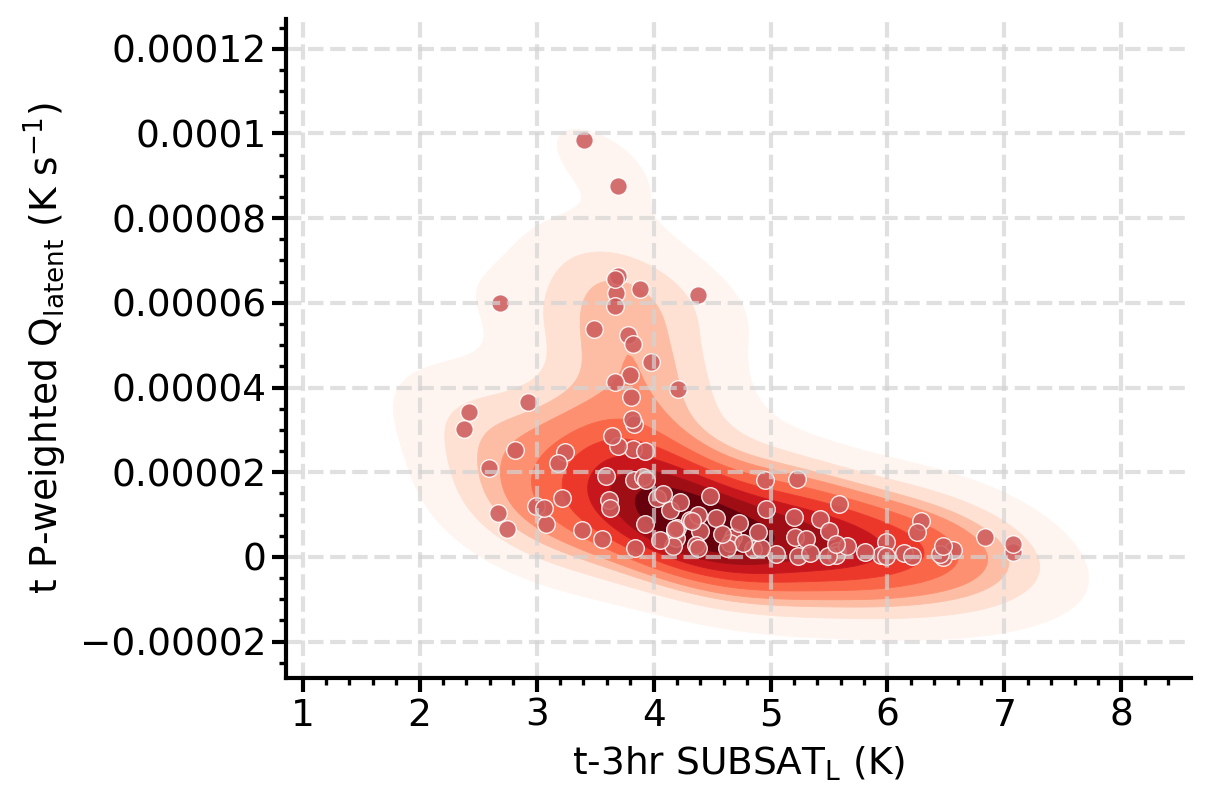

In [52]:
fig, axs = plot.subplots(ncols=1, nrows=1, figsize=(6.05,4.05), share=True)
sns.kdeplot(
    data=cyclone_data, x="subsat", y="hdia", fill=True,ax=axs[0],cmap='Reds'
)
sns.scatterplot( data=cyclone_data, x="subsat", y="hdia",ax=axs[0],s=40,alpha=0.87,edgecolors='w',c='indianred')
axs.format(#ylim=(1000,100),
           xlabel='t-3hr SUBSAT$_{L}$ (K)', ylabel='t P-weighted Q$_{latent}$ (K s$^{-1}$)')
plt.tight_layout()
plt.savefig('./pics/T3subsatl_Qlat_wrfmemb03.png',dpi=400)
plt.show()